## Define Paths and File Catalogue

In [55]:
import sys, json, subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path('..').resolve()
SCRIPTS_DIR  = PROJECT_ROOT / 'scripts'
DATA_PATH    = PROJECT_ROOT / 'single-cell-tracks_exp1-6_noErbB2.csv.gz'
META_PATH    = PROJECT_ROOT / '01-readme-experiment-description_2022-04-05.csv'
OUTPUT_ROOT  = PROJECT_ROOT / 'analysis_outputs'
CSV_ROOT = PROJECT_ROOT / 'outputs'

SIGNAL_COL = 'ERKKTR_ratio'
print('Setup complete.')

Setup complete.


## Run script to prepare the data

In [3]:
print('Running cohort comparison for ERK …')
cmd = [
    sys.executable,
    str(SCRIPTS_DIR / 'compare_spatiotemporal_behavior.py'),
    '--data-path', str(DATA_PATH),
    '--meta-path', str(META_PATH),
    '--signal-col', 'ERKKTR_ratio',
    '--group-by', 'mutation',
    '--spatial-radius', '60',
    '--future-window-frames', '3',
    '--jump-quantile', '0.9',
    '--include-mutations',
    'WT',
    'AKT1_E17K',
    'PIK3CA_E545K',
    'PIK3CA_H1047R',
    'PTEN_del',
    '--output-dir', str(OUTPUT_ROOT),
]
r_erk = subprocess.run(
    cmd, 
    capture_output=True, 
    text=True,
    check=True)
print(r_erk.stdout[-800:])  # tail of stdout

Running cohort comparison for ERK …
 0.054427                0.127974                  0.073547        2.079152e+06        326484.583333
    PIK3CA_E545K        24               4                     6      8443205            1.707110              1.688656              0.059877                0.145206                  0.085329        2.385621e+06        349580.125000
       AKT1_E17K        21               4                     6      8797999            1.581421              1.453965              0.053217                0.152170                  0.098953        3.450509e+06        417039.285714
        PTEN_del        27               8                     6      5764607            1.556633              1.555826              0.045523                0.127909                  0.082386        9.433794e+05        212421.111111



## Load group-level and block-level RR summaries

In [56]:
# Load group-level summary statistics
df = pd.read_csv(
    OUTPUT_ROOT / "comparison_mutation_ERKKTR_ratio" / "group_level_summary.csv"
)

# Load block-level summary statistics
df2 = pd.read_csv(
    OUTPUT_ROOT / "comparison_mutation_ERKKTR_ratio" / "block_level_summary.csv"
)

# Keep only mutation labels and RR values
relative_risk_only = df2[["relative_risk", "mutation"]]

print(relative_risk_only)

# Sanity checks
print("Groups found:", df["comparison_group"].unique())

print("\nMean RR:")
print(df["mean_relative_risk"])

# Create simplified summary table
only_mean = df[["comparison_group", "mean_relative_risk"]]

print("\nClean table:")
print(only_mean)

     relative_risk   mutation
0         1.755850         WT
1         1.768681         WT
2         1.628362         WT
3         1.880994         WT
4         1.610885  AKT1_E17K
..             ...        ...
115       1.385638   PTEN_del
116       1.598182   PTEN_del
117       1.766534   PTEN_del
118       1.589821   PTEN_del
119       1.558808   PTEN_del

[120 rows x 2 columns]
Groups found: <StringArray>
['PIK3CA_H1047R', 'WT', 'PIK3CA_E545K', 'AKT1_E17K', 'PTEN_del']
Length: 5, dtype: str

Mean RR:
0    3.200310
1    1.742349
2    1.707110
3    1.581421
4    1.556633
Name: mean_relative_risk, dtype: float64

Clean table:
  comparison_group  mean_relative_risk
0    PIK3CA_H1047R            3.200310
1               WT            1.742349
2     PIK3CA_E545K            1.707110
3        AKT1_E17K            1.581421
4         PTEN_del            1.556633


## Mann–Whitney U test with Bonferroni correction

In [78]:
from scipy.stats import mannwhitneyu, sem
from statsmodels.stats.multitest import multipletests

df = pd.read_csv(
    OUTPUT_ROOT / "comparison_mutation_ERKKTR_ratio" / "group_level_summary.csv"
)

df2=pd.read_csv(
    OUTPUT_ROOT / "comparison_mutation_ERKKTR_ratio" / "block_level_summary.csv"
)

summary_stats = df2.groupby("mutation")["relative_risk"].agg([
    ("std_error", sem) 
]).reset_index()

relative_risk_only=df2[["relative_risk","mutation"]]
print(relative_risk_only)

# sanity checks
print("Groups found:", df["comparison_group"].unique())

print("\nMean RR:")
print(df["mean_relative_risk"])

only_mean = df[["comparison_group", "mean_relative_risk"]]

only_mean = only_mean.rename(columns={
    "comparison_group": "mutation"
})

print("\nClean table:")
print(only_mean)

stats=pd.merge(
    only_mean,
    summary_stats,
    on="mutation",
    how="inner"
)


wt = df2.loc[
    df2["mutation"] == "WT",
    "relative_risk"
].dropna()

mutants = [
    "AKT1_E17K",
    "PIK3CA_E545K",
    "PIK3CA_H1047R",
    "PTEN_del"
]

# p-values from Mann–Whitney
p_raw = []

for mut in mutants:
    mut_rr = df2.loc[df2["mutation"] == mut, "relative_risk"].dropna()
    stat, p = mannwhitneyu(wt, mut_rr, alternative="two-sided")
    p_raw.append(p)

df_results = pd.DataFrame({
    "mutation": mutants,
    "p_raw": p_raw
})

# Add WT row manually (no statistical comparison vs itself)
wt_row = pd.DataFrame({
    "mutation": ["WT"],
    "p_raw": [np.nan],
    "p_value_vs_WT": [np.nan],
    "significant": [None]
})

# Combine WT with mutant test results
df_results = pd.concat([wt_row, df_results], ignore_index=True)

# Bonferroni correction
reject, p_corr, _, _ = multipletests(
    df_results["p_raw"],
    alpha=0.05,
    method="bonferroni"
)

df_results["p_value_vs_WT"] = p_corr
df_results["significant"] = reject

print(df_results)

df_final = pd.merge(
    stats,
    df_results,
    on="mutation",
    how="inner"
)

     relative_risk   mutation
0         1.755850         WT
1         1.768681         WT
2         1.628362         WT
3         1.880994         WT
4         1.610885  AKT1_E17K
..             ...        ...
115       1.385638   PTEN_del
116       1.598182   PTEN_del
117       1.766534   PTEN_del
118       1.589821   PTEN_del
119       1.558808   PTEN_del

[120 rows x 2 columns]
Groups found: <StringArray>
['PIK3CA_H1047R', 'WT', 'PIK3CA_E545K', 'AKT1_E17K', 'PTEN_del']
Length: 5, dtype: str

Mean RR:
0    3.200310
1    1.742349
2    1.707110
3    1.581421
4    1.556633
Name: mean_relative_risk, dtype: float64

Clean table:
        mutation  mean_relative_risk
0  PIK3CA_H1047R            3.200310
1             WT            1.742349
2   PIK3CA_E545K            1.707110
3      AKT1_E17K            1.581421
4       PTEN_del            1.556633
        mutation         p_raw  p_value_vs_WT  significant
0             WT           NaN            NaN        False
1      AKT1_E17K  3.461467

In [79]:
# Sanity check

df_final

,mutation,mean_relative_risk,std_error,p_raw,p_value_vs_WT,significant
0,PIK3CA_H1047R,3.200310,0.130643,3.063664e-09,1.531832e-08,True
1,WT,1.742349,0.017193,NaN,NaN,False
2,PIK3CA_E545K,1.707110,0.031885,1.835290e-01,9.176448e-01,False
3,AKT1_E17K,1.581421,0.071932,3.461467e-03,1.730733e-02,True
4,PTEN_del,1.556633,0.021624,3.660584e-07,1.830292e-06,True


## Save data

In [ ]:
export_table = df_final[[
    "mutation", "mean_relative_risk", "std_error", "p_value_vs_WT", "significant"
]]
export_table.to_csv(CSV_ROOT/"mutations_comparison_table.csv", index=False)
print("Table mutations_comparison_table.csvwas saved.")


Tabela mutations_comparison_table.csvwas saved.


## Plots

/var/folders/db/bz5chhv95qs4p1sw6k437dm40000gn/T/ipykernel_36734/4088812425.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


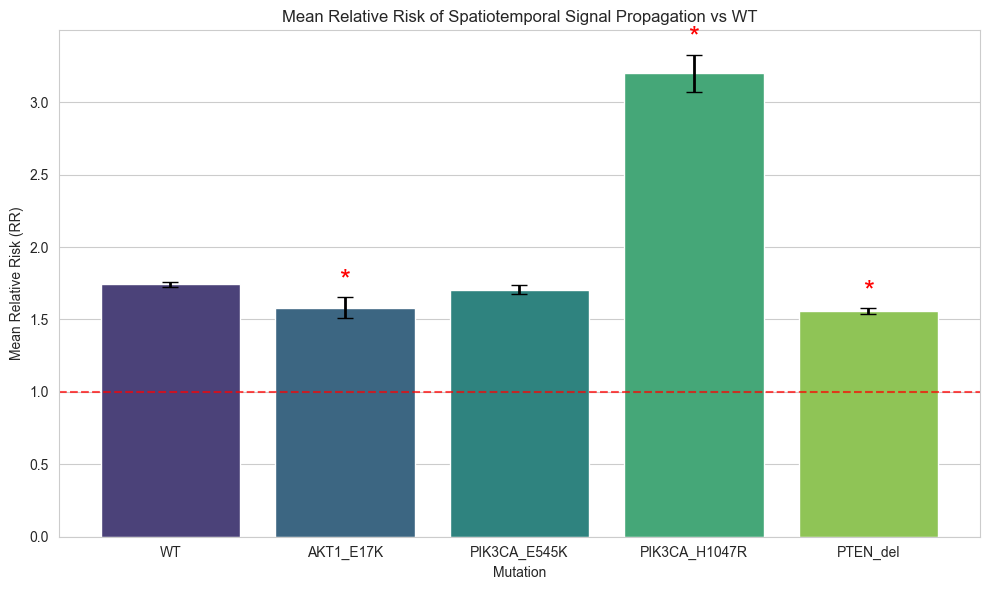

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# WT appears first
mutation_order = [
    "WT",
    "AKT1_E17K",
    "PIK3CA_E545K",
    "PIK3CA_H1047R",
    "PTEN_del"
]

df_final["mutation"] = pd.Categorical(
    df_final["mutation"],
    categories=mutation_order,
    ordered=True
)

df_final = df_final.sort_values("mutation")
df_final = df_final.reset_index(drop=True)

# Bar plot
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

ax = sns.barplot(
    data=df_final, 
    x="mutation", 
    y="mean_relative_risk", 
    palette="viridis",
    capsize=.1
)

# Error bars
plt.errorbar(
    x=range(len(df_final)), 
    y=df_final["mean_relative_risk"], 
    yerr=df_final["std_error"], 
    fmt='none',
    ecolor='black',
    elinewidth=2,
    capsize=6,
    capthick=1
)

# RR = 1 reference line
plt.axhline(
    y=1,
    linestyle='--',
    color='red',
    linewidth=1.5,
    alpha=0.7
)


# Add significance markers for p < 0.05
for i, row in df_final.iterrows():
    if row["significant"]:
        ax.text(
            i,
            row["mean_relative_risk"] + row["std_error"] + 0.02,
            "*", 
            ha='center',
            va='bottom',
            fontsize=20,
            color='red'
        )

# Final plot formatting and export
plt.title("Mean Relative Risk of Spatiotemporal Signal Propagation vs WT")
plt.ylabel("Mean Relative Risk (RR)")
plt.xlabel("Mutation")

plt.tight_layout()

plt.savefig(CSV_ROOT/"rr_comparison_plot.png")

plt.show()